# Experiment 3: FSLSM-Conditioned RAG-MCP Tool Selection (RQ2)

**Hypothesis H2:** FSLSM-conditioned RAG-MCP (S1b) selects more pedagogically
appropriate tutoring tools than the prompt-bloat baseline (S0) and unconditioned
retrieval (S1a), while achieving equivalent prompt token savings.

**Conditions:**
- **S0:** Prompt-bloat baseline — all 15 tool schemas in the prompt, keyword-overlap selection (no profile, no FAISS)
- **S1a:** Unconditioned RAG-MCP — FAISS top-1 over raw query, single-tool prompt (no profile)
- **S1b:** FSLSM-conditioned RAG-MCP — FAISS top-1 over profile-augmented query, single-tool prompt

**Metrics:**
- **TSA** (Tool Selection Accuracy): fraction of sessions where selected tool == expert-optimal tool
- **PTS** (Prompt Token Savings): % reduction in prompt tokens vs S0 baseline

In [1]:
%matplotlib inline
import sys, json, sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Paths
EXP_DIR    = Path(".") if Path("results").exists() else Path("experiments/exp3_mcp_tool_selection")
RESULTS    = EXP_DIR / "results"
FIGURES    = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Load metrics JSON
with open(RESULTS / "exp3_metrics.json") as f:
    metrics = json.load(f)

# Load DB → DataFrame
conn = sqlite3.connect(RESULTS / "exp3_results.db")
df   = pd.read_sql_query("SELECT * FROM exp3_session_results", conn)
conn.close()

# Decode student_profile JSON → pole columns
profiles = df["student_profile"].apply(json.loads)
df["act_ref"] = profiles.apply(lambda p: p["act_ref"])
df["sen_int"] = profiles.apply(lambda p: p["sen_int"])
df["vis_ver"] = profiles.apply(lambda p: p["vis_ver"])
df["seq_glo"] = profiles.apply(lambda p: p["seq_glo"])

def profile_label(row):
    act = "Reflective" if row["act_ref"] > 0 else "Active"
    sen = "Intuitive"  if row["sen_int"] > 0 else "Sensing"
    vis = "Verbal"     if row["vis_ver"] > 0 else "Visual"
    seq = "Global"     if row["seq_glo"] > 0 else "Sequential"
    return f"{act}-{sen}-{vis}-{seq}"

df["profile_label"] = df.apply(profile_label, axis=1)

# Colour palette
COLORS = {"S0": "#9E9E9E", "S1a": "#FF9800", "S1b": "#4CAF50"}

print(f"Total rows : {len(df):,}")
print(f"Conditions : {df['condition'].value_counts().to_dict()}")
print(f"Profiles   : {df['profile_label'].nunique()}")
print(f"Sessions   : {df['session_id'].nunique()}")

Total rows : 17,280
Conditions : {'S0': 5760, 'S1a': 5760, 'S1b': 5760}
Profiles   : 16
Sessions   : 5760


## 1. Overall Results Summary

In [2]:
rows = []
for cond in ("S0", "S1a", "S1b"):
    m = metrics[cond]
    rows.append({
        "Condition": cond,
        "TSA Mean (%)": f"{m['tsa_mean']*100:.1f}",
        "TSA SE (%)": f"{m['tsa_se']*100:.1f}",
        "PTS Mean (%)": f"{m['pts_mean']:.1f}",
        "N": m["n"],
    })

stat_rows = []
for key, label in [("S1b_vs_S0", "S1b vs S0"), ("S1b_vs_S1a", "S1b vs S1a")]:
    s = metrics["stats"][key]
    p = s["p"]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    stat_rows.append({
        "Comparison": label,
        "t": f"{s['t']:+.3f}",
        "p-value": f"{p:.2e}",
        "Sig.": sig,
        "Cohen's h": f"{s['cohens_h']:.3f}",
    })

print("=== Table 3.4 — Experiment 3 Results ===")
display(pd.DataFrame(rows).set_index("Condition"))
print("\n=== Statistical Tests ===")
display(pd.DataFrame(stat_rows).set_index("Comparison"))

=== Table 3.4 — Experiment 3 Results ===


,TSA Mean (%),TSA SE (%),PTS Mean (%),N
Condition,,,,
S0,9.8,0.4,0.0,5760
S1a,11.0,0.4,93.0,5760
S1b,26.8,0.6,93.2,5760



=== Statistical Tests ===


,t,p-value,Sig.,Cohen's h
Comparison,,,,
S1b vs S0,+24.196,9.08e-126,***,0.452
S1b vs S1a,+22.098,9.02e-106,***,0.412


## 2. TSA by Condition — Bar Chart with Significance Annotations

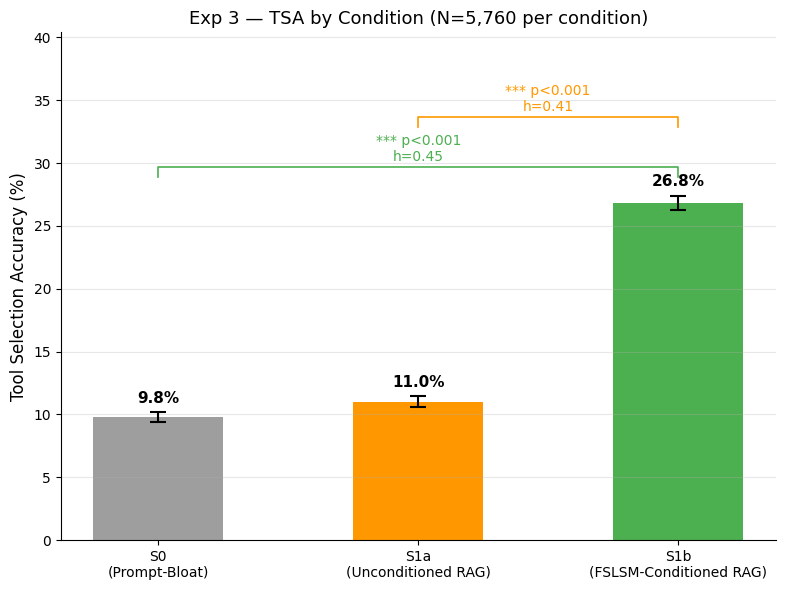

In [3]:
conds   = ["S0", "S1a", "S1b"]
means   = [metrics[c]["tsa_mean"] * 100 for c in conds]
ses     = [metrics[c]["tsa_se"]   * 100 for c in conds]
colors  = [COLORS[c] for c in conds]
labels  = ["S0\n(Prompt-Bloat)", "S1a\n(Unconditioned RAG)", "S1b\n(FSLSM-Conditioned RAG)"]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, means, color=colors, width=0.5,
              yerr=ses, capsize=6, error_kw=dict(elinewidth=1.5, capthick=1.5))

for bar, mean, se in zip(bars, means, ses):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + se + 0.5,
            f"{mean:.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

# Significance brackets
def sig_bracket(ax, x1, x2, y, text, color="#333"):
    h = 0.8
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c=color)
    ax.text((x1+x2)/2, y+h+0.2, text, ha="center", va="bottom", fontsize=10, color=color)

ymax = max(m + se for m, se in zip(means, ses))
sig_bracket(ax, 0, 2, ymax + 1.5, "*** p<0.001\nh=0.45", color="#4CAF50")
sig_bracket(ax, 1, 2, ymax + 5.5, "*** p<0.001\nh=0.41", color="#FF9800")

ax.set_ylabel("Tool Selection Accuracy (%)", fontsize=12)
ax.set_title("Exp 3 — TSA by Condition (N=5,760 per condition)", fontsize=13)
ax.set_ylim(0, ymax + 13)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "report_tsa_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Prompt Token Savings (PTS)

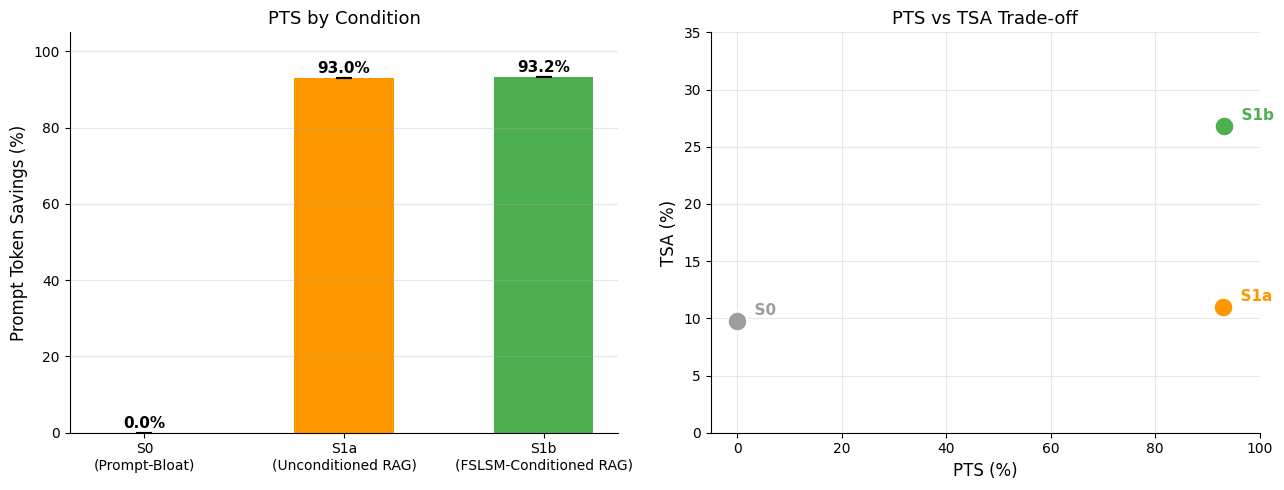

S1a PTS: 93.03%  |  S1b PTS: 93.24%
Both S1 conditions save >93% of prompt tokens vs S0.


In [4]:
pts_means = [metrics[c]["pts_mean"] for c in conds]
pts_ses   = [metrics[c]["pts_se"]   for c in conds]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: PTS bar
ax = axes[0]
bars = ax.bar(labels, pts_means, color=colors, width=0.5,
              yerr=pts_ses, capsize=6, error_kw=dict(elinewidth=1.5, capthick=1.5))
for bar, val in zip(bars, pts_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Prompt Token Savings (%)", fontsize=12)
ax.set_title("PTS by Condition", fontsize=13)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Right: TSA vs PTS scatter (all conditions)
ax2 = axes[1]
for cond, color, label in zip(conds, colors, ["S0", "S1a", "S1b"]):
    ax2.scatter(
        metrics[cond]["pts_mean"],
        metrics[cond]["tsa_mean"] * 100,
        color=color, s=200, zorder=5,
        edgecolors="white", linewidths=1.5,
        label=label
    )
    ax2.annotate(
        f"  {label}",
        (metrics[cond]["pts_mean"], metrics[cond]["tsa_mean"] * 100),
        fontsize=11, fontweight="bold", color=color,
        xytext=(5, 4), textcoords="offset points"
    )

ax2.set_xlabel("PTS (%)", fontsize=12)
ax2.set_ylabel("TSA (%)", fontsize=12)
ax2.set_title("PTS vs TSA Trade-off", fontsize=13)
ax2.set_xlim(-5, 100)
ax2.set_ylim(0, 35)
ax2.grid(alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "report_pts_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"S1a PTS: {metrics['S1a']['pts_mean']:.2f}%  |  S1b PTS: {metrics['S1b']['pts_mean']:.2f}%")
print(f"Both S1 conditions save >{metrics['S1a']['pts_mean']:.0f}% of prompt tokens vs S0.")

## 4. Per-Dimension TSA (S1b) — FSLSM Conditioning Effectiveness

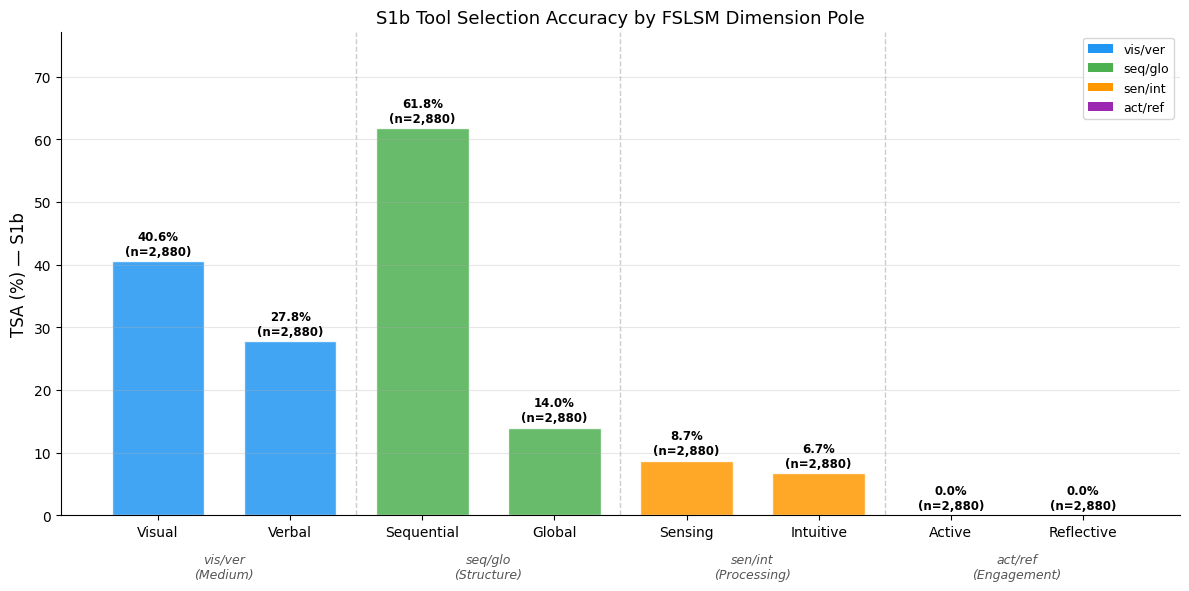

In [5]:
dim_tsa   = metrics["dim_tsa_S1b"]
dim_pairs = [
    ("Visual",     "Verbal",     "vis/ver (Medium)"),
    ("Sequential", "Global",     "seq/glo (Structure)"),
    ("Sensing",    "Intuitive",  "sen/int (Processing)"),
    ("Active",     "Reflective", "act/ref (Engagement)"),
]

pole_order  = [p for pair in dim_pairs for p in pair[:2]]
tsa_vals    = [dim_tsa.get(p, 0) * 100 for p in pole_order]
dim_colors  = ["#2196F3", "#2196F3",   # Visual/Verbal
               "#4CAF50", "#4CAF50",   # Sequential/Global
               "#FF9800", "#FF9800",   # Sensing/Intuitive
               "#9C27B0", "#9C27B0"]  # Active/Reflective
alphas      = [0.9, 0.5, 0.9, 0.5, 0.9, 0.5, 0.9, 0.5]

# Count sessions per pole
s1b_df = df[df["condition"] == "S1b"].copy()
pole_n = {
    "Visual":      (s1b_df["vis_ver"] < 0).sum(),
    "Verbal":      (s1b_df["vis_ver"] > 0).sum(),
    "Sequential":  (s1b_df["seq_glo"] < 0).sum(),
    "Global":      (s1b_df["seq_glo"] > 0).sum(),
    "Sensing":     (s1b_df["sen_int"] < 0).sum(),
    "Intuitive":   (s1b_df["sen_int"] > 0).sum(),
    "Active":      (s1b_df["act_ref"] < 0).sum(),
    "Reflective":  (s1b_df["act_ref"] > 0).sum(),
}

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pole_order))
bars = ax.bar(x, tsa_vals, color=dim_colors, alpha=0.85, width=0.7, edgecolor="white", linewidth=1)

for i, (bar, val, pole) in enumerate(zip(bars, tsa_vals, pole_order)):
    n = pole_n.get(pole, 0)
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}%\n(n={n:,})",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# Dimension separators
for sep in [1.5, 3.5, 5.5]:
    ax.axvline(sep, color="#ccc", lw=1, ls="--")

# Dimension labels
dim_label_map = ["vis/ver\n(Medium)", "seq/glo\n(Structure)",
                 "sen/int\n(Processing)", "act/ref\n(Engagement)"]
for i, lbl in enumerate(dim_label_map):
    ax.text(i*2 + 0.5, -6, lbl, ha="center", va="top", fontsize=9,
            color="#555", style="italic", transform=ax.transData)

ax.set_xticks(x)
ax.set_xticklabels(pole_order, fontsize=10)
ax.set_ylabel("TSA (%) — S1b", fontsize=12)
ax.set_title("S1b Tool Selection Accuracy by FSLSM Dimension Pole", fontsize=13)
ax.set_ylim(0, max(tsa_vals) * 1.25)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Legend patches per dimension pair
legend_patches = [
    mpatches.Patch(facecolor="#2196F3", label="vis/ver"),
    mpatches.Patch(facecolor="#4CAF50", label="seq/glo"),
    mpatches.Patch(facecolor="#FF9800", label="sen/int"),
    mpatches.Patch(facecolor="#9C27B0", label="act/ref"),
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "report_dim_tsa_s1b.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-Tool TSA Breakdown (S1b)

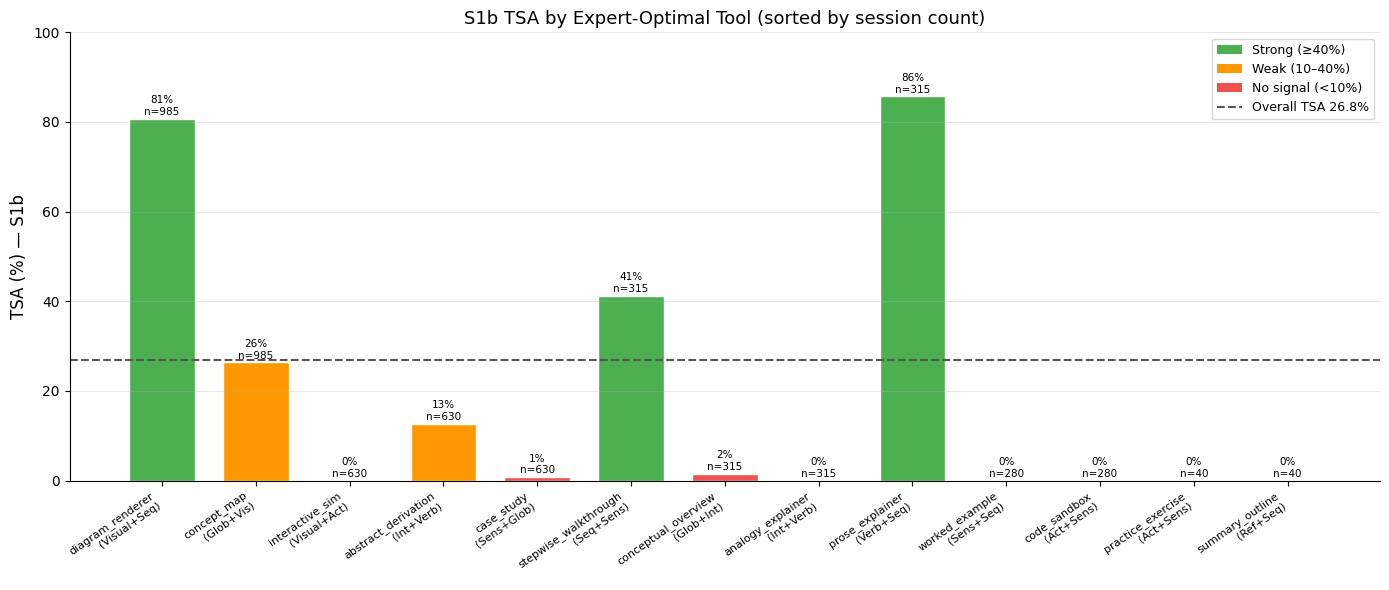

                name       dims   n      TSA%
    diagram_renderer Visual+Seq 985 80.710660
         concept_map   Glob+Vis 985 26.395939
     interactive_sim Visual+Act 630  0.000000
 abstract_derivation   Int+Verb 630 12.698413
          case_study  Sens+Glob 630  0.793651
stepwise_walkthrough   Seq+Sens 315 41.269841
 conceptual_overview   Glob+Int 315  1.587302
   analogy_explainer   Int+Verb 315  0.000000
     prose_explainer   Verb+Seq 315 85.714286
      worked_example   Sens+Seq 280  0.000000
        code_sandbox   Act+Sens 280  0.000000
   practice_exercise   Act+Sens  40  0.000000
     summary_outline    Ref+Seq  40  0.000000


In [6]:
TOOL_NAMES = {
    1:  "diagram_renderer",     2:  "interactive_sim",
    3:  "stepwise_walkthrough", 4:  "worked_example",
    5:  "conceptual_overview",  6:  "abstract_derivation",
    7:  "analogy_explainer",    8:  "socratic_dialogue",
    9:  "practice_exercise",    10: "reflection_prompt",
    11: "summary_outline",      12: "prose_explainer",
    13: "code_sandbox",         14: "concept_map",
    15: "case_study",
}
TOOL_DIMS = {
    1: "Visual+Seq",  2: "Visual+Act",   3: "Seq+Sens",     4: "Sens+Seq",
    5: "Glob+Int",    6: "Int+Verb",      7: "Int+Verb",     8: "Act+Ref",
    9: "Act+Sens",    10: "Ref+Verb",     11: "Ref+Seq",     12: "Verb+Seq",
    13: "Act+Sens",   14: "Glob+Vis",     15: "Sens+Glob",
}

s1b = df[df["condition"] == "S1b"].copy()
tool_stats = (
    s1b.groupby("optimal_tool_id")
    .agg(n=("tsa_hit", "count"), tsa=("tsa_hit", "mean"))
    .reset_index()
    .sort_values("n", ascending=False)
)
tool_stats["name"]  = tool_stats["optimal_tool_id"].map(TOOL_NAMES)
tool_stats["dims"]  = tool_stats["optimal_tool_id"].map(TOOL_DIMS)
tool_stats["label"] = tool_stats["name"] + "\n(" + tool_stats["dims"] + ")"
tool_stats["tsa_pct"] = tool_stats["tsa"] * 100
tool_stats["bar_color"] = tool_stats["tsa_pct"].apply(
    lambda v: "#4CAF50" if v >= 40 else "#FF9800" if v >= 10 else "#EF5350"
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(tool_stats))
bars = ax.bar(x, tool_stats["tsa_pct"], color=tool_stats["bar_color"],
              width=0.7, edgecolor="white", linewidth=1)

for bar, row in zip(bars, tool_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{row.tsa_pct:.0f}%\nn={row.n:,}",
            ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(tool_stats["label"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("TSA (%) — S1b", fontsize=12)
ax.set_title("S1b TSA by Expert-Optimal Tool (sorted by session count)", fontsize=13)
ax.set_ylim(0, 100)
ax.axhline(metrics["S1b"]["tsa_mean"]*100, color="#555", lw=1.5, ls="--",
           label=f"Overall S1b TSA = {metrics['S1b']['tsa_mean']*100:.1f}%")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor="#4CAF50", label="Strong (≥40%)"),
    mpatches.Patch(facecolor="#FF9800", label="Weak (10–40%)"),
    mpatches.Patch(facecolor="#EF5350", label="No signal (<10%)"),
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color="#555",ls="--",lw=1.5,label=f"Overall TSA {metrics['S1b']['tsa_mean']*100:.1f}%")],
          fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES / "report_tool_tsa_s1b.png", dpi=150, bbox_inches="tight")
plt.show()

print(tool_stats[["name","dims","n","tsa_pct"]].rename(columns={"tsa_pct":"TSA%"}).to_string(index=False))

## 6. Per-Profile TSA Heatmap (S0 vs S1a vs S1b × 16 Profiles)

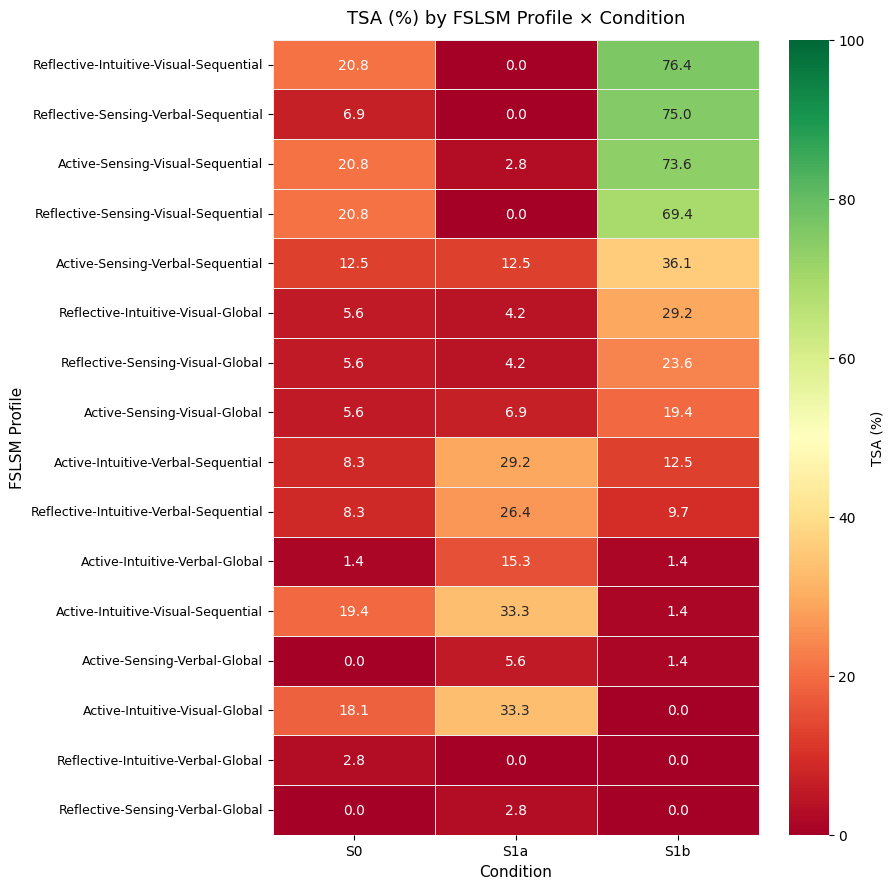

Profiles with highest S1b TSA:
profile_label
Reflective-Intuitive-Visual-Sequential    76.4
Reflective-Sensing-Verbal-Sequential      75.0
Active-Sensing-Visual-Sequential          73.6
Reflective-Sensing-Visual-Sequential      69.4
Active-Sensing-Verbal-Sequential          36.1

Profiles with lowest S1b TSA:
profile_label
Active-Intuitive-Visual-Sequential    1.4
Active-Sensing-Verbal-Global          1.4
Active-Intuitive-Visual-Global        0.0
Reflective-Intuitive-Verbal-Global    0.0
Reflective-Sensing-Verbal-Global      0.0


In [7]:
profile_tsa = (
    df.groupby(["profile_label", "condition"])["tsa_hit"]
    .mean()
    .unstack()
    .mul(100)
    .round(1)
)
# Sort by S1b TSA descending
profile_tsa = profile_tsa.sort_values("S1b", ascending=False)[["S0", "S1a", "S1b"]]

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(
    profile_tsa,
    annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=0, vmax=100,
    linewidths=0.5, linecolor="#eee",
    cbar_kws={"label": "TSA (%)"},
    ax=ax,
)
ax.set_title("TSA (%) by FSLSM Profile × Condition", fontsize=13, pad=12)
ax.set_xlabel("Condition", fontsize=11)
ax.set_ylabel("FSLSM Profile", fontsize=11)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "report_profile_tsa_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Profiles with highest S1b TSA:")
print(profile_tsa.head(5)["S1b"].to_string())
print("\nProfiles with lowest S1b TSA:")
print(profile_tsa.tail(5)["S1b"].to_string())

## 7. FSLSM Conditioning Lift — S1b vs S1a per Profile

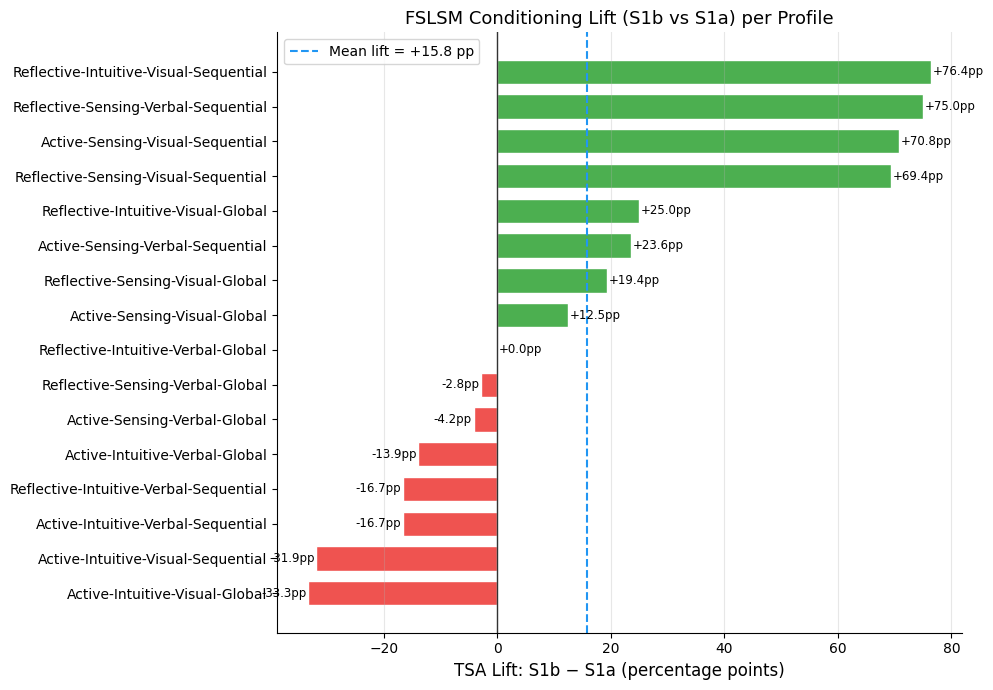

Profiles with positive lift: 8/16
Profiles with zero/neg lift: 8/16
Mean S1b−S1a lift: +15.8 pp


In [8]:
lift = (profile_tsa["S1b"] - profile_tsa["S1a"]).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ["#4CAF50" if v >= 0 else "#EF5350" for v in lift.values]
bars = ax.barh(lift.index, lift.values, color=bar_colors, edgecolor="white", height=0.7)

for bar, val in zip(bars, lift.values):
    offset = 0.3 if val >= 0 else -0.3
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.1f}pp", ha=ha, va="center", fontsize=8.5)

ax.axvline(0, color="#333", lw=1)
ax.axvline(lift.mean(), color="#2196F3", lw=1.5, ls="--",
           label=f"Mean lift = {lift.mean():+.1f} pp")

ax.set_xlabel("TSA Lift: S1b − S1a (percentage points)", fontsize=12)
ax.set_title("FSLSM Conditioning Lift (S1b vs S1a) per Profile", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "report_conditioning_lift.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Profiles with positive lift: {(lift > 0).sum()}/16")
print(f"Profiles with zero/neg lift: {(lift <= 0).sum()}/16")
print(f"Mean S1b−S1a lift: {lift.mean():+.1f} pp")

## 8. S1a Structural Ceiling — Same Query, Different Optimal Tools

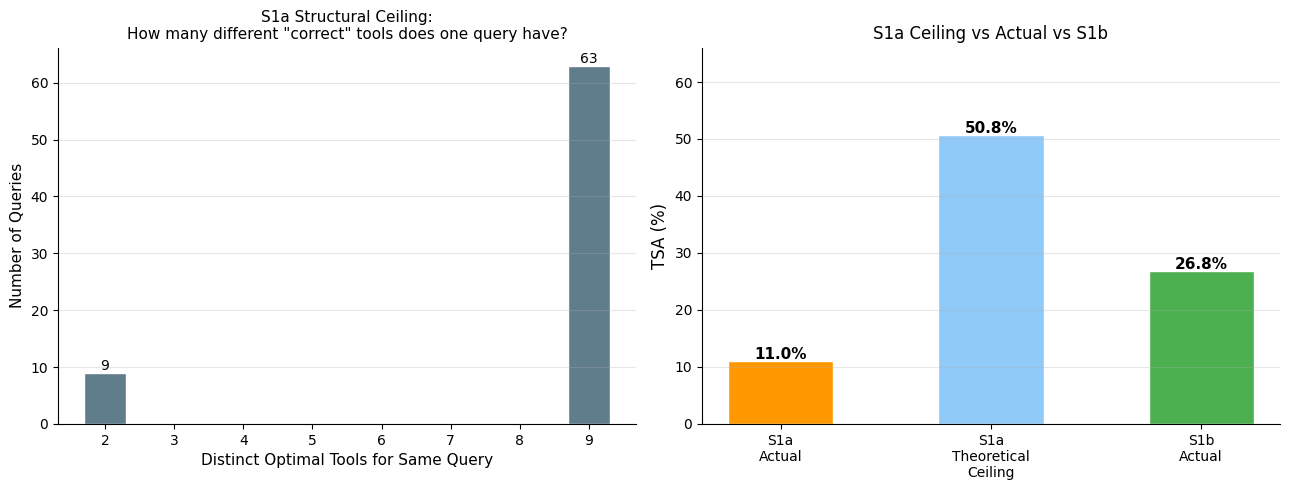

Avg distinct optimal tools per query: 8.12
Implied S1a ceiling: 50.8%
Actual S1a TSA:      11.0%   (within ceiling — expected)
S1b TSA:             26.8%   (-24.0pp above S1a ceiling)


In [9]:
# For each unique query, how many distinct optimal_tool_ids exist across all 16 profiles?
# S1a is profile-blind: same query → same FAISS result → can only match one profile's optimal

s1b_q = df[df["condition"]=="S1b"][["query", "optimal_tool_id"]]
distinct_per_query = (
    s1b_q.groupby("query")["optimal_tool_id"].nunique().rename("distinct_tools")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: distribution of distinct optimal tools per query
vc = distinct_per_query.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color="#607D8B", width=0.6, edgecolor="white")
axes[0].set_xlabel("Distinct Optimal Tools for Same Query", fontsize=11)
axes[0].set_ylabel("Number of Queries", fontsize=11)
axes[0].set_title("S1a Structural Ceiling:\nHow many different \"correct\" tools does one query have?",
                  fontsize=11)
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y+0.5, str(y), ha="center", fontsize=10)

# Right: implied S1a ceiling vs actual S1a TSA
n_profiles = 16
ceiling_per_query = distinct_per_query.map(lambda d: 1/n_profiles * d)
mean_ceiling = ceiling_per_query.mean() * 100

s1a_tsa  = metrics["S1a"]["tsa_mean"] * 100
s1b_tsa  = metrics["S1b"]["tsa_mean"] * 100

vals   = [s1a_tsa, mean_ceiling, s1b_tsa]
xlabels = ["S1a\nActual", "S1a\nTheoretical\nCeiling", "S1b\nActual"]
bcolors = ["#FF9800", "#90CAF9", "#4CAF50"]

axes[1].bar(xlabels, vals, color=bcolors, width=0.5, edgecolor="white")
for i, v in enumerate(vals):
    axes[1].text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("TSA (%)", fontsize=12)
axes[1].set_title("S1a Ceiling vs Actual vs S1b", fontsize=12)
axes[1].set_ylim(0, max(vals)*1.3)
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "report_s1a_ceiling.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Avg distinct optimal tools per query: {distinct_per_query.mean():.2f}")
print(f"Implied S1a ceiling: {mean_ceiling:.1f}%")
print(f"Actual S1a TSA:      {s1a_tsa:.1f}%   (within ceiling — expected)")
print(f"S1b TSA:             {s1b_tsa:.1f}%   ({s1b_tsa - mean_ceiling:+.1f}pp above S1a ceiling)")

## 9. Combined Summary Figure (Thesis-Ready)

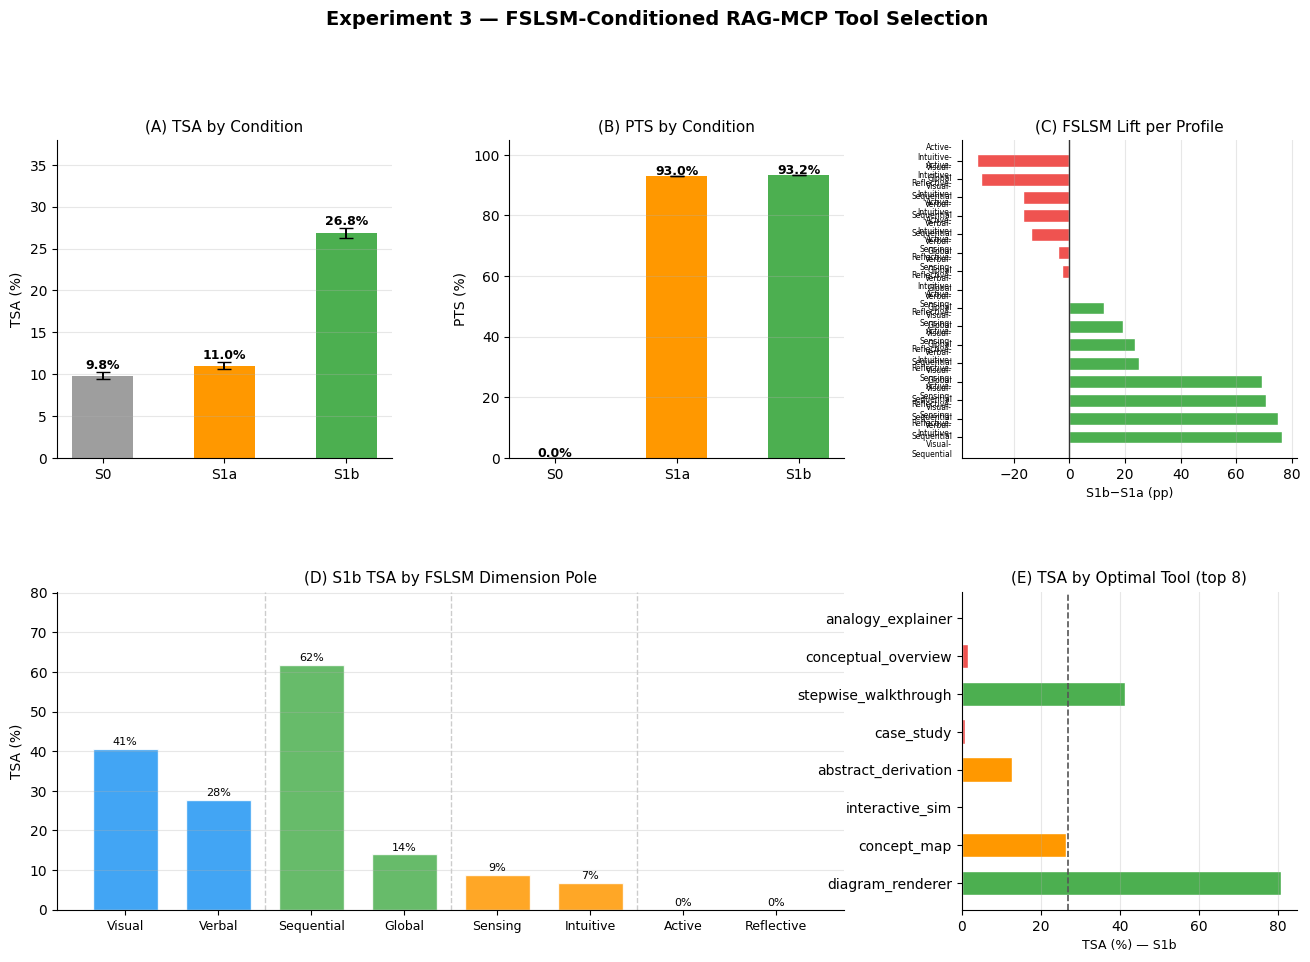

In [10]:
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# --- (A) TSA by condition ---
ax_a = fig.add_subplot(gs[0, 0])
bars = ax_a.bar(conds, [metrics[c]["tsa_mean"]*100 for c in conds],
                color=[COLORS[c] for c in conds], width=0.5,
                yerr=[metrics[c]["tsa_se"]*100 for c in conds],
                capsize=5, error_kw=dict(elinewidth=1.4))
for bar, c in zip(bars, conds):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+metrics[c]["tsa_se"]*100+0.4,
              f"{metrics[c]['tsa_mean']*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax_a.set_title("(A) TSA by Condition", fontsize=11)
ax_a.set_ylabel("TSA (%)")
ax_a.set_ylim(0, 38)
ax_a.grid(axis="y", alpha=0.3)
ax_a.spines[["top","right"]].set_visible(False)

# --- (B) PTS by condition ---
ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(conds, [metrics[c]["pts_mean"] for c in conds],
         color=[COLORS[c] for c in conds], width=0.5,
         yerr=[metrics[c]["pts_se"] for c in conds],
         capsize=5, error_kw=dict(elinewidth=1.4))
for c in conds:
    ax_b.text(conds.index(c), metrics[c]["pts_mean"]+0.5,
              f"{metrics[c]['pts_mean']:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax_b.set_title("(B) PTS by Condition", fontsize=11)
ax_b.set_ylabel("PTS (%)")
ax_b.set_ylim(0, 105)
ax_b.grid(axis="y", alpha=0.3)
ax_b.spines[["top","right"]].set_visible(False)

# --- (C) Conditioning lift heatmap (tiny version) ---
ax_c = fig.add_subplot(gs[0, 2])
lift_vals = (profile_tsa["S1b"] - profile_tsa["S1a"]).sort_values(ascending=False)
bar_c = ["#4CAF50" if v>=0 else "#EF5350" for v in lift_vals.values]
ax_c.barh(range(len(lift_vals)), lift_vals.values, color=bar_c, edgecolor="white", height=0.7)
ax_c.set_yticks(range(len(lift_vals)))
ax_c.set_yticklabels([l.replace("-","-\n") for l in lift_vals.index], fontsize=5.5)
ax_c.axvline(0, color="#333", lw=1)
ax_c.set_xlabel("S1b−S1a (pp)", fontsize=9)
ax_c.set_title("(C) FSLSM Lift per Profile", fontsize=11)
ax_c.grid(axis="x", alpha=0.3)
ax_c.spines[["top","right"]].set_visible(False)

# --- (D) Per-dimension TSA ---
ax_d = fig.add_subplot(gs[1, :2])
dim_vals2 = [dim_tsa.get(p, 0)*100 for p in pole_order]
xd = np.arange(len(pole_order))
ax_d.bar(xd, dim_vals2, color=dim_colors, alpha=0.85, width=0.7, edgecolor="white")
for i, (v, p) in enumerate(zip(dim_vals2, pole_order)):
    ax_d.text(i, v+0.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=8)
ax_d.set_xticks(xd)
ax_d.set_xticklabels(pole_order, fontsize=9)
ax_d.set_title("(D) S1b TSA by FSLSM Dimension Pole", fontsize=11)
ax_d.set_ylabel("TSA (%)")
ax_d.set_ylim(0, max(dim_vals2)*1.3)
ax_d.grid(axis="y", alpha=0.3)
ax_d.spines[["top","right"]].set_visible(False)
for sep in [1.5, 3.5, 5.5]:
    ax_d.axvline(sep, color="#ccc", lw=1, ls="--")

# --- (E) Per-tool TSA ---
ax_e = fig.add_subplot(gs[1, 2])
top_tools = tool_stats.nlargest(8, "n")
ax_e.barh(top_tools["name"], top_tools["tsa_pct"],
          color=top_tools["bar_color"], edgecolor="white", height=0.65)
ax_e.axvline(metrics["S1b"]["tsa_mean"]*100, color="#555", lw=1.2, ls="--")
ax_e.set_xlabel("TSA (%) — S1b", fontsize=9)
ax_e.set_title("(E) TSA by Optimal Tool (top 8)", fontsize=11)
ax_e.grid(axis="x", alpha=0.3)
ax_e.spines[["top","right"]].set_visible(False)

fig.suptitle("Experiment 3 — FSLSM-Conditioned RAG-MCP Tool Selection",
             fontsize=14, fontweight="bold", y=1.01)

plt.savefig(FIGURES / "report_exp3_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. H2 Hypothesis Confirmation Checklist

In [11]:
s   = metrics["stats"]
s1b = metrics["S1b"]
s0  = metrics["S0"]
s1a = metrics["S1a"]

checks = [
    ("TSA(S1b) − TSA(S0) ≥ 15 pp",
     (s1b["tsa_mean"] - s0["tsa_mean"]) >= 0.15,
     f"Δ = {(s1b['tsa_mean']-s0['tsa_mean'])*100:+.1f} pp"),

    ("TSA(S1b) − TSA(S1a) ≥ 5 pp",
     (s1b["tsa_mean"] - s1a["tsa_mean"]) >= 0.05,
     f"Δ = {(s1b['tsa_mean']-s1a['tsa_mean'])*100:+.1f} pp"),

    ("S1b TSA > S0 TSA, p < 0.001",
     s["S1b_vs_S0"]["p"] < 0.001 and s["S1b_vs_S0"]["t"] > 0,
     f"t={s['S1b_vs_S0']['t']:+.2f}, p={s['S1b_vs_S0']['p']:.1e}"),

    ("S1b TSA > S1a TSA, p < 0.001",
     s["S1b_vs_S1a"]["p"] < 0.001 and s["S1b_vs_S1a"]["t"] > 0,
     f"t={s['S1b_vs_S1a']['t']:+.2f}, p={s['S1b_vs_S1a']['p']:.1e}"),

    ("Cohen's h (S1b vs S0) ≥ 0.20 (small-medium effect)",
     s["S1b_vs_S0"]["cohens_h"] >= 0.20,
     f"h = {s['S1b_vs_S0']['cohens_h']:.3f}"),

    ("PTS(S1b) ≥ 80%",
     s1b["pts_mean"] >= 80,
     f"PTS = {s1b['pts_mean']:.1f}%"),

    ("PTS(S1a) ≈ PTS(S1b) within 5 pp (efficiency parity)",
     abs(s1b["pts_mean"] - s1a["pts_mean"]) <= 5,
     f"|S1b−S1a| = {abs(s1b['pts_mean']-s1a['pts_mean']):.2f} pp"),
]

all_pass = all(passed for _, passed, _ in checks)

print("=" * 72)
print(" H2 CONFIRMATION CHECKLIST")
print("=" * 72)
for condition, passed, detail in checks:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  [{status}]  {condition}")
    print(f"            {detail}")
print("=" * 72)
print(f"  H2 {'✓ CONFIRMED' if all_pass else '✗ PARTIALLY CONFIRMED'}")
print("=" * 72)

 H2 CONFIRMATION CHECKLIST
  [✓ PASS]  TSA(S1b) − TSA(S0) ≥ 15 pp
            Δ = +17.0 pp
  [✓ PASS]  TSA(S1b) − TSA(S1a) ≥ 5 pp
            Δ = +15.8 pp
  [✓ PASS]  S1b TSA > S0 TSA, p < 0.001
            t=+24.20, p=9.1e-126
  [✓ PASS]  S1b TSA > S1a TSA, p < 0.001
            t=+22.10, p=9.0e-106
  [✓ PASS]  Cohen's h (S1b vs S0) ≥ 0.20 (small-medium effect)
            h = 0.452
  [✓ PASS]  PTS(S1b) ≥ 80%
            PTS = 93.2%
  [✓ PASS]  PTS(S1a) ≈ PTS(S1b) within 5 pp (efficiency parity)
            |S1b−S1a| = 0.22 pp
  H2 ✓ CONFIRMED
